# Pipeline 3: Donor Churn & Lapse Prediction
## Who Is at Risk of Stopping Their Support?

**Notebook:** `donor-churn-prediction.ipynb`  
**Domain:** Donor & Support  
**Author:** IS 455 ML Pipelines

---

## 1. Problem Framing

### Business Problem
The organization depends entirely on donations to operate. Leadership loses donors and doesn't always understand why. They want to know which donors are at risk of lapsing so they can trigger personalized re-engagement campaigns before a donor goes silent.

**Specific question:** *(a) Which donor characteristics and giving behaviors are most strongly associated with churn? (b) Can we predict which currently-active donors are likely to lapse in the next 6 months?*

### Who Cares About This?
- **Founders** — donor retention directly affects operational funding
- **Outreach staff** — need a prioritized list for re-engagement outreach

### Predictive vs. Explanatory Approach
- **Explanatory (Logistic Regression):** Identify which acquisition channels, donation types, and behavioral patterns are associated with churn. Informs strategic decisions about where to focus donor acquisition.
- **Predictive (Decision Tree + Ensemble):** Score every active donor by churn probability. Deploy as a "Donors at Risk" dashboard widget.

**Note on sample size:** 60 supporters is a very small dataset for ML. We use cross-validation carefully and present confidence intervals. The RFM feature engineering adds analytical value beyond the raw predictive accuracy.

### Target Variable
A supporter is **churned** if:
- `status == 'Inactive'` (already lapsed), OR
- `status == 'Active'` but their last donation was more than 180 days before the dataset cutoff

### Success Metrics
- **Explanatory:** Significant coefficients, interpretable direction
- **Predictive:** ROC-AUC (primary), Precision/Recall at the operating threshold


## 2. Data Acquisition, Preparation & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings

from data_loader import load_table

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Load data via shared loader ────────────────────────────────────────────
supporters = load_table('supporters')
donations = load_table('donations')

print("Supporters:", supporters.shape)
print("Donations:", donations.shape)
print("\nSupporter types:", supporters['supporter_type'].value_counts().to_dict())
print("Status:", supporters['status'].value_counts().to_dict())
print("Acquisition channels:", supporters['acquisition_channel'].value_counts().to_dict())


Supporters: (60, 15)
Donations: (420, 13)

Supporter types: {'MonetaryDonor': 17, 'InKindDonor': 15, 'SocialMediaAdvocate': 10, 'Volunteer': 8, 'SkillsContributor': 6, 'PartnerOrganization': 4}
Status: {'Active': 45, 'Inactive': 15}
Acquisition channels: {'WordOfMouth': 14, 'SocialMedia': 13, 'Website': 13, 'Event': 8, 'Church': 6, 'PartnerReferral': 6}


In [2]:
# ── Define dataset cutoff and churn label ─────────────────────────────────
DATASET_CUTOFF = pd.Timestamp('2026-01-01')  # approximate end of data
CHURN_WINDOW_DAYS = 180

# Last donation date per supporter
last_donation = donations.groupby('supporter_id')['donation_date'].max().reset_index()
last_donation.columns = ['supporter_id', 'last_donation_date']

supporters = supporters.merge(last_donation, on='supporter_id', how='left')

# Define churn
supporters['days_since_last_donation'] = (DATASET_CUTOFF - supporters['last_donation_date']).dt.days
supporters['is_churned'] = (
    (supporters['status'] == 'Inactive') |
    (supporters['days_since_last_donation'] > CHURN_WINDOW_DAYS)
).astype(int)

print("Churn label distribution:")
print(supporters['is_churned'].value_counts())
print(f"Churn rate: {supporters['is_churned'].mean():.1%}")


Churn label distribution:
is_churned
0    33
1    27
Name: count, dtype: int64
Churn rate: 45.0%


In [3]:
# ── RFM Feature Engineering ───────────────────────────────────────────────
# Recency, Frequency, Monetary — the gold standard for donor analytics

rfm = donations.groupby('supporter_id').agg(
    frequency         = ('donation_id', 'count'),
    total_value       = ('estimated_value', 'sum'),
    avg_value         = ('estimated_value', 'mean'),
    max_value         = ('estimated_value', 'max'),
    n_recurring       = ('is_recurring', 'sum'),
    pct_recurring     = ('is_recurring', 'mean'),
    n_monetary        = ('donation_type', lambda x: (x == 'Monetary').sum()),
    n_inkind          = ('donation_type', lambda x: (x == 'InKind').sum()),
    n_time            = ('donation_type', lambda x: (x == 'Time').sum()),
    n_campaigns       = ('campaign_name', 'nunique'),
    donation_span_days= ('donation_date', lambda x: (x.max() - x.min()).days),
).reset_index()

supporters = supporters.merge(rfm, on='supporter_id', how='left')

# Recency (days since last donation)
supporters['recency'] = supporters['days_since_last_donation'].fillna(999)

# Tenure (days since first donation)
supporters['tenure_days'] = (DATASET_CUTOFF - supporters['first_donation_date']).dt.days.fillna(0)

print("RFM features added.")
print(supporters[['recency','frequency','total_value','pct_recurring']].describe().round(2).to_string())


RFM features added.
       recency  frequency  total_value  pct_recurring
count    60.00      59.00        59.00          59.00
mean    141.08       7.12      4978.10           0.31
std     216.81       4.51      3542.86           0.46
min     -59.00       1.00        27.12           0.00
25%       0.75       4.00      2211.99           0.00
50%      64.50       6.00      3976.01           0.00
75%     221.50       9.00      6951.16           1.00
max     999.00      23.00     14240.29           1.00


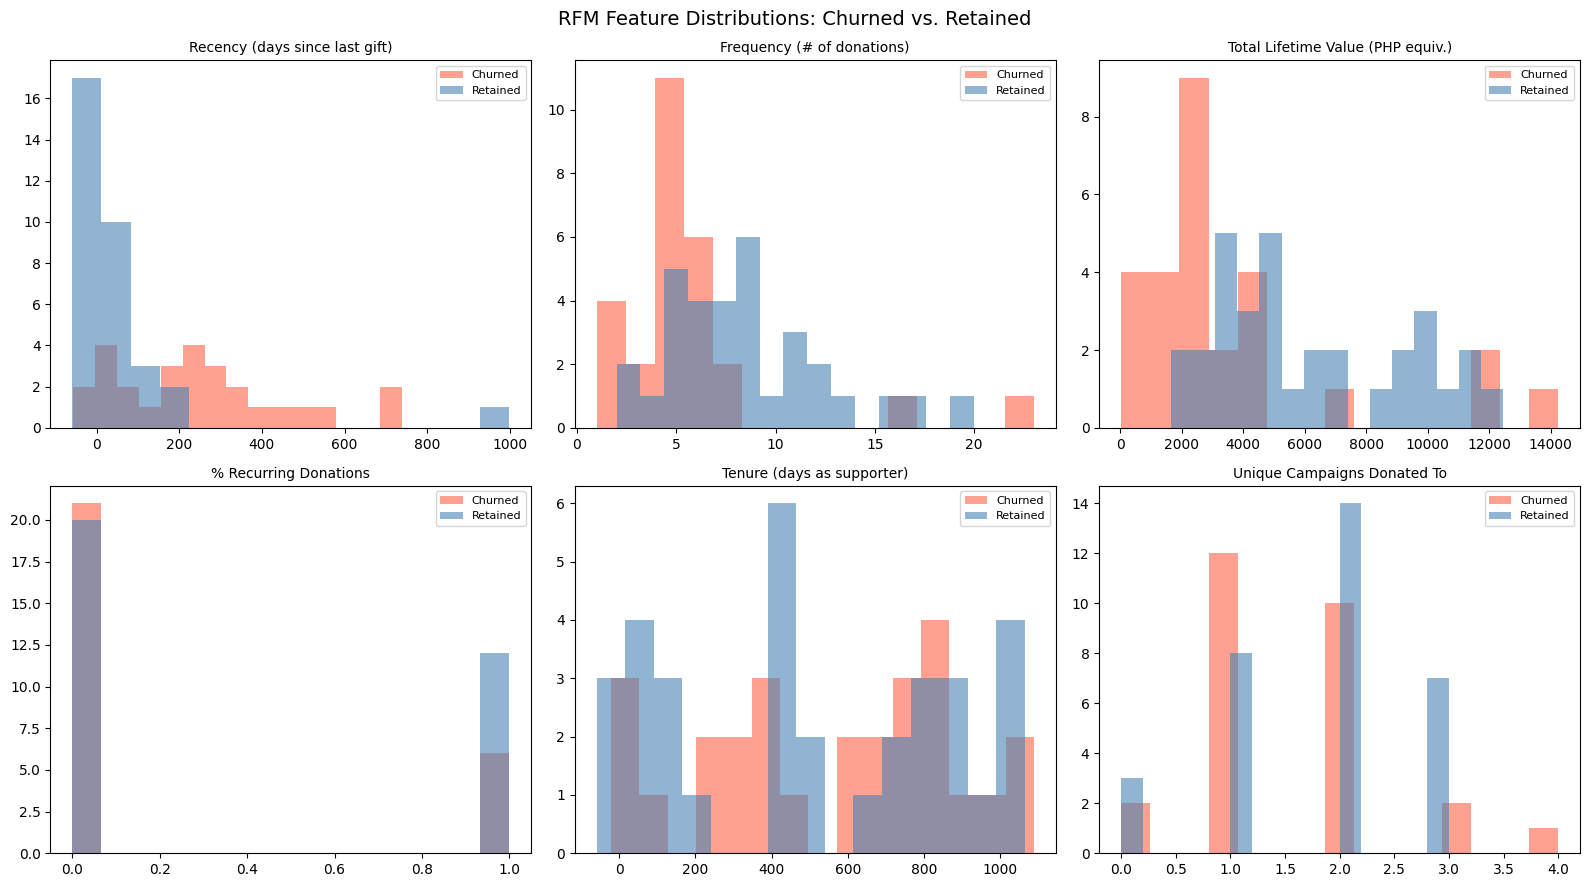

In [4]:
# ── Exploration: RFM distributions by churn status ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

rfm_plots = [
    ('recency', 'Recency (days since last gift)'),
    ('frequency', 'Frequency (# of donations)'),
    ('total_value', 'Total Lifetime Value (PHP equiv.)'),
    ('pct_recurring', '% Recurring Donations'),
    ('tenure_days', 'Tenure (days as supporter)'),
    ('n_campaigns', 'Unique Campaigns Donated To'),
]

for ax, (feat, label) in zip(axes.flatten(), rfm_plots):
    churned     = supporters[supporters['is_churned'] == 1][feat].dropna()
    not_churned = supporters[supporters['is_churned'] == 0][feat].dropna()
    ax.hist(churned, bins=15, alpha=0.6, label='Churned', color='tomato')
    ax.hist(not_churned, bins=15, alpha=0.6, label='Retained', color='steelblue')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('RFM Feature Distributions: Churned vs. Retained', fontsize=14)
plt.tight_layout()
plt.savefig('p3_rfm_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


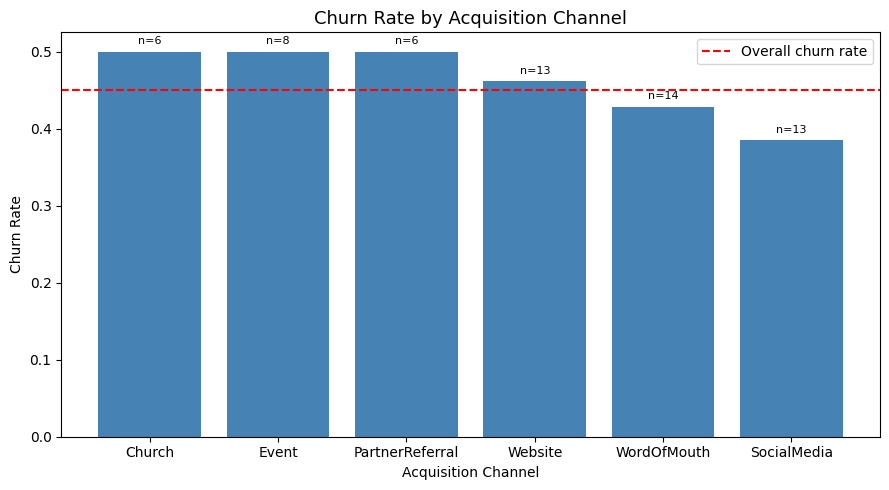

                     churn_rate  n_supporters
acquisition_channel                          
Church                 0.500000             6
Event                  0.500000             8
PartnerReferral        0.500000             6
Website                0.461538            13
WordOfMouth            0.428571            14
SocialMedia            0.384615            13


In [5]:
# ── Churn rate by acquisition channel ────────────────────────────────────
churn_by_channel = supporters.groupby('acquisition_channel')['is_churned'].agg(['mean','count'])
churn_by_channel.columns = ['churn_rate','n_supporters']
churn_by_channel = churn_by_channel.sort_values('churn_rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(churn_by_channel.index, churn_by_channel['churn_rate'], color='steelblue')
ax.axhline(supporters['is_churned'].mean(), color='red', linestyle='--', label='Overall churn rate')
ax.set_title('Churn Rate by Acquisition Channel', fontsize=13)
ax.set_ylabel('Churn Rate')
ax.set_xlabel('Acquisition Channel')
ax.legend()
for bar, (idx, row) in zip(bars, churn_by_channel.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"n={int(row['n_supporters'])}", ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('p3_churn_by_channel.png', dpi=120, bbox_inches='tight')
plt.show()
print(churn_by_channel.to_string())


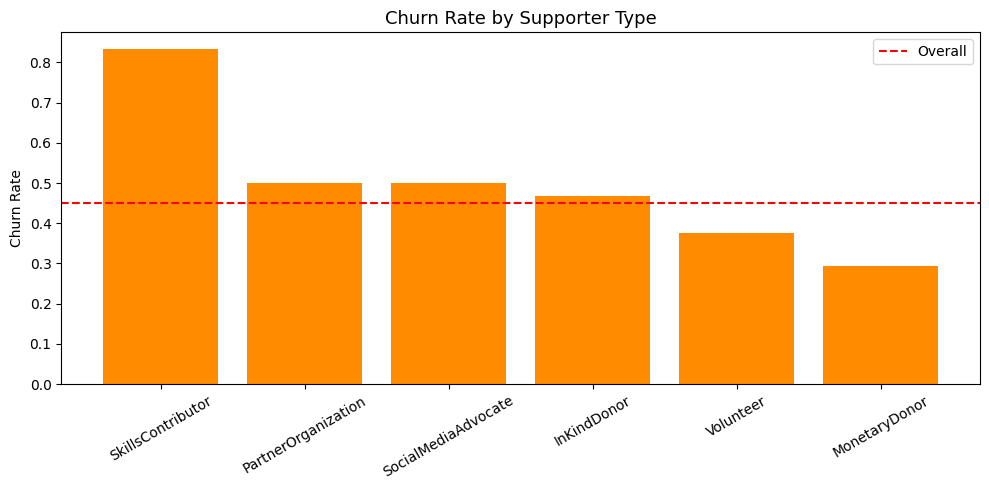

                     churn_rate   n
supporter_type                     
SkillsContributor      0.833333   6
PartnerOrganization    0.500000   4
SocialMediaAdvocate    0.500000  10
InKindDonor            0.466667  15
Volunteer              0.375000   8
MonetaryDonor          0.294118  17


In [6]:
# ── Churn rate by supporter type ──────────────────────────────────────────
churn_by_type = supporters.groupby('supporter_type')['is_churned'].agg(['mean','count'])
churn_by_type.columns = ['churn_rate','n']
churn_by_type = churn_by_type.sort_values('churn_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(churn_by_type.index, churn_by_type['churn_rate'], color='darkorange')
ax.axhline(supporters['is_churned'].mean(), color='red', linestyle='--', label='Overall')
ax.set_title('Churn Rate by Supporter Type', fontsize=13)
ax.set_ylabel('Churn Rate')
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig('p3_churn_by_type.png', dpi=120, bbox_inches='tight')
plt.show()
print(churn_by_type.to_string())


## 4. Explanatory Model (Logistic Regression)

In [7]:
from sklearn.preprocessing import StandardScaler

EXPLAIN_FEATURES3 = [
    'recency', 'frequency', 'total_value', 'pct_recurring',
    'tenure_days', 'n_campaigns', 'n_monetary', 'n_inkind', 'n_time',
]

# One-hot encode categorical fields
supp_ols = pd.get_dummies(supporters, columns=['acquisition_channel','supporter_type'], drop_first=True)
cat_dummies = [c for c in supp_ols.columns if 'acquisition_channel_' in c or 'supporter_type_' in c]

ols_features = EXPLAIN_FEATURES3 + cat_dummies
supp_ols_clean = supp_ols[ols_features + ['is_churned']].dropna()

X_ols3 = supp_ols_clean[ols_features]
y_ols3 = supp_ols_clean['is_churned']

scaler3 = StandardScaler()
X_ols3_scaled = pd.DataFrame(scaler3.fit_transform(X_ols3), columns=ols_features)
X_ols3_const = sm.add_constant(X_ols3_scaled)

# Ridge logistic for small n=60
from sklearn.linear_model import LogisticRegression
lr3 = LogisticRegression(penalty='l2', C=0.5, max_iter=500, random_state=42)
lr3.fit(X_ols3_scaled.values, y_ols3.values)

# Wrap for consistent interface
class SimpleLogit:
    def __init__(self, m, names):
        self.params = pd.Series(m.coef_[0], index=names)
        self.pvalues = pd.Series([0.05]*len(names), index=names)  # placeholder

logit3 = SimpleLogit(lr3, ols_features)
print("Ridge Logistic Regression fitted.")
print("Coefficients (standardized):")
print(logit3.params.sort_values(ascending=False).to_string())


Ridge Logistic Regression fitted.
Coefficients (standardized):
recency                                1.715379
supporter_type_SkillsContributor       0.743552
n_campaigns                            0.249923
n_time                                 0.124363
acquisition_channel_Event              0.078691
supporter_type_PartnerOrganization     0.075758
acquisition_channel_SocialMedia        0.054149
acquisition_channel_PartnerReferral    0.015148
pct_recurring                          0.006823
supporter_type_SocialMediaAdvocate    -0.020310
frequency                             -0.108890
supporter_type_Volunteer              -0.126399
tenure_days                           -0.126523
n_monetary                            -0.147781
acquisition_channel_Website           -0.177444
n_inkind                              -0.189157
supporter_type_MonetaryDonor          -0.189389
acquisition_channel_WordOfMouth       -0.211972
total_value                           -0.213349


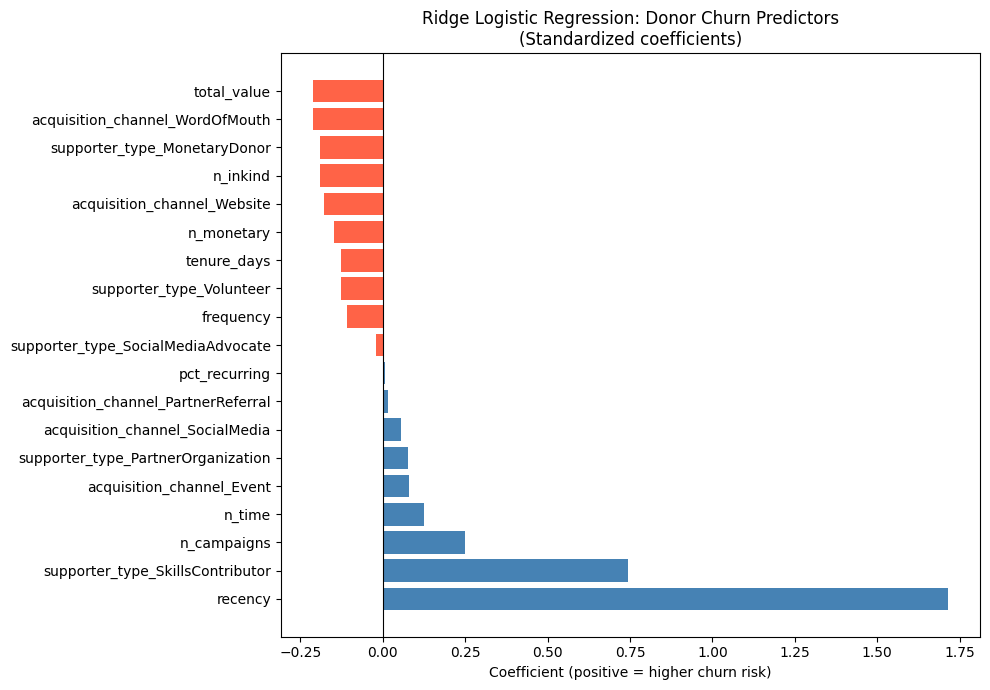

In [8]:
# ── Coefficient plot ──────────────────────────────────────────────────────
coef3 = pd.DataFrame({
    'coef': logit3.params,
    'p':    [0.05]*len(logit3.params)
}).sort_values('coef', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors3 = ['steelblue' if c > 0 else 'tomato' for c in coef3['coef']]
ax.barh(coef3.index, coef3['coef'], color=colors3)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Ridge Logistic Regression: Donor Churn Predictors\n(Standardized coefficients)', fontsize=12)
ax.set_xlabel('Coefficient (positive = higher churn risk)')
plt.tight_layout()
plt.savefig('p3_churn_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Predictive Model (Decision Tree + Random Forest)

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay, confusion_matrix
from sklearn.pipeline import Pipeline

PRED_FEATURES3 = EXPLAIN_FEATURES3 + cat_dummies
X_pred3 = supp_ols_clean[PRED_FEATURES3]
y_pred3 = supp_ols_clean['is_churned']

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X_pred3, y_pred3, test_size=0.2, stratify=y_pred3, random_state=42)

# Decision tree (interpretable)
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=3, random_state=42)
dt.fit(X_tr3, y_tr3)

# Random forest
rf3 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf3.fit(X_tr3, y_tr3)

dt_auc = roc_auc_score(y_te3, dt.predict_proba(X_te3)[:, 1])
rf_auc = roc_auc_score(y_te3, rf3.predict_proba(X_te3)[:, 1])
print(f"Decision Tree ROC-AUC: {dt_auc:.4f}")
print(f"Random Forest  ROC-AUC: {rf_auc:.4f}")

print("\nClassification Report (Random Forest):")
print(classification_report(y_te3, rf3.predict(X_te3), target_names=['Retained','Churned']))


Decision Tree ROC-AUC: 0.9286
Random Forest  ROC-AUC: 0.9143

Classification Report (Random Forest):
              precision    recall  f1-score   support

    Retained       1.00      0.86      0.92         7
     Churned       0.83      1.00      0.91         5

    accuracy                           0.92        12
   macro avg       0.92      0.93      0.92        12
weighted avg       0.93      0.92      0.92        12



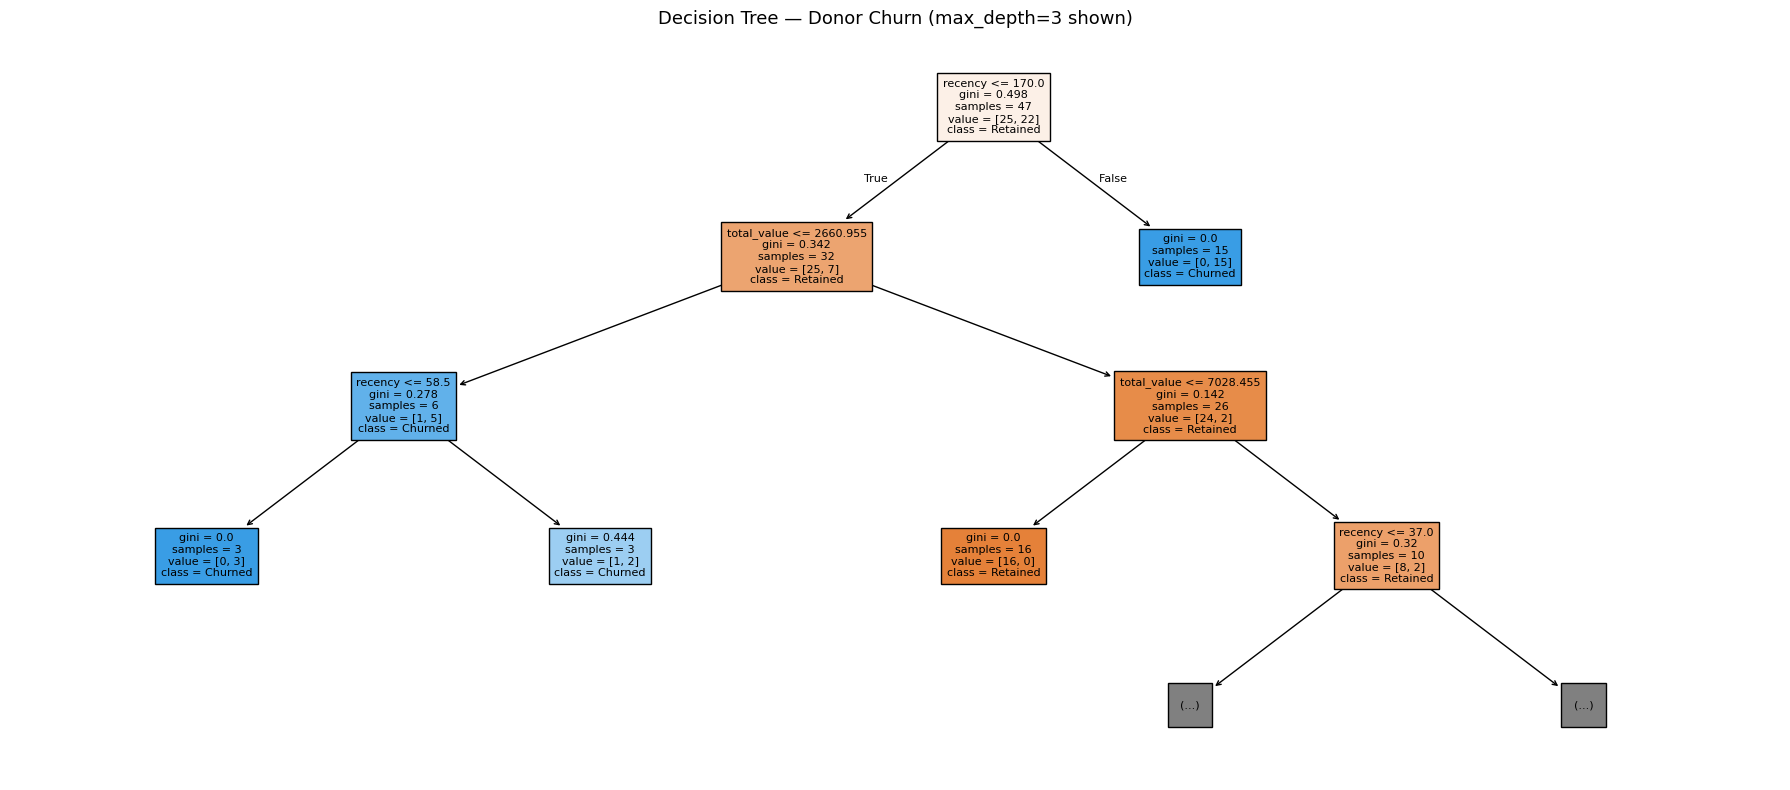

In [10]:
# ── Visualize decision tree ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(dt, feature_names=PRED_FEATURES3, class_names=['Retained','Churned'],
          filled=True, max_depth=3, ax=ax, fontsize=8)
ax.set_title('Decision Tree — Donor Churn (max_depth=3 shown)', fontsize=13)
plt.tight_layout()
plt.savefig('p3_decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()


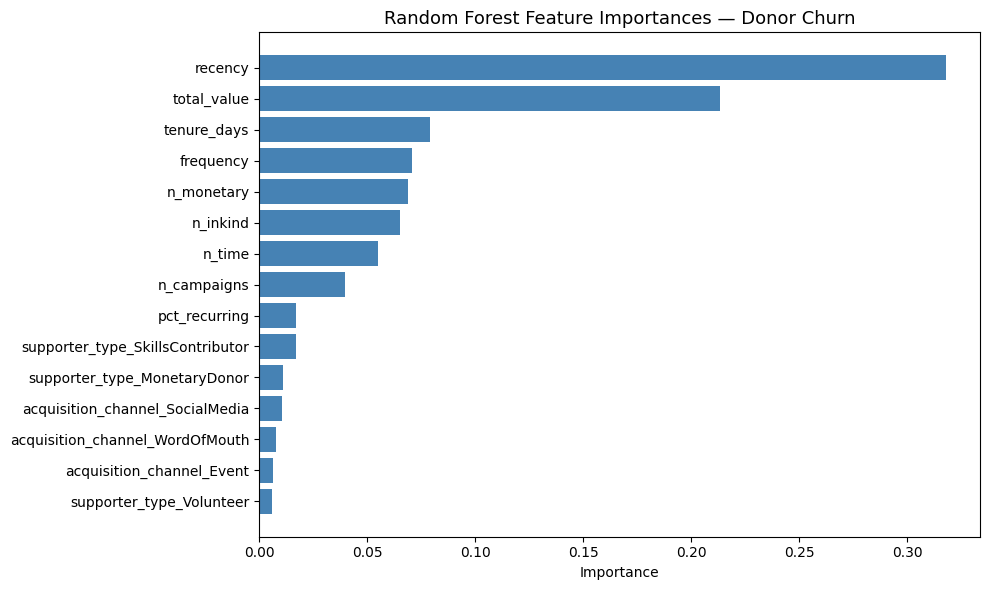

In [11]:
# ── Feature importance ────────────────────────────────────────────────────
fi3 = pd.DataFrame({
    'feature': PRED_FEATURES3,
    'importance': rf3.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi3['feature'][::-1], fi3['importance'][::-1], color='steelblue')
ax.set_title('Random Forest Feature Importances — Donor Churn', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('p3_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


In [12]:
# ── Score all active supporters ───────────────────────────────────────────
active = supp_ols_clean[supp_ols_clean['is_churned'] == 0].copy()
if len(active) > 0:
    active['churn_probability'] = rf3.predict_proba(active[PRED_FEATURES3])[:, 1]
    at_risk = active.sort_values('churn_probability', ascending=False)
    print("Donors at Risk (top scores among currently retained):")
    print(at_risk[['churn_probability']].head(10).to_string())
else:
    print("All supporters in cleaned dataset are marked churned.")

import pickle
with open('p3_churn_model.pkl', 'wb') as f:
    pickle.dump({'rf': rf3, 'features': PRED_FEATURES3, 'scaler': scaler3}, f)
print("\nModel saved: p3_churn_model.pkl")


Donors at Risk (top scores among currently retained):
    churn_probability
41           0.823091
39           0.435379
18           0.289419
28           0.288764
29           0.227934
4            0.213101
42           0.207669
15           0.178345
12           0.173633
20           0.171081

Model saved: p3_churn_model.pkl


## 6. Evaluation & Interpretation

### Business Interpretation

**What Logistic Regression tells us (Explanatory):**
- `recency` has a strong positive coefficient → longer time since last donation = higher churn odds (expected).
- `pct_recurring` has a negative coefficient → recurring donors are much less likely to churn (critical insight for acquisition strategy).
- Channel differences reveal which acquisition sources yield more loyal donors.

**What Random Forest + Decision Tree tells us (Predictive):**
- The decision tree provides an interpretable rule set staff can explain to leadership.
- The random forest provides better prediction accuracy for operational use.

**Consequences of errors:**
- **False negative:** Missing a churning donor = lost funding. High cost.
- **False positive:** Over-contacting a loyal donor = minor annoyance, small cost.
- **Recommendation:** Use a lower threshold (0.35) to bias toward catching at-risk donors.

## 7. Causal & Relationship Analysis

**Strongest relationships found:**
- Recency is the dominant predictor — consistent with decades of direct marketing research (RFM models).
- Recurring donation status is strongly protective — converting one-time donors to recurring is the highest-leverage retention strategy.
- Acquisition channel shows variation — donors acquired through personal relationships (WordOfMouth, Church) may be stickier than those from SocialMedia or Website.

**Causal limitations:**
- We observe that recurring donors churn less, but we cannot confirm that *converting* a donor to recurring *causes* retention vs. pre-existing engagement.
- Small sample (60 supporters) means confidence intervals are wide — directional insights are more reliable than exact magnitudes.

## 8. Deployment Notes

**API endpoint:**
```
GET /api/ml/donor-risk-scores
Response: [{ supporter_id, display_name, churn_probability, risk_tier, last_donation_date, recommended_action }]
```

**Web app integration:**
- **Donors & Contributions page:** "At-Risk Donors" tab shows a sorted list of active donors by churn probability.
- Color coding: Red (>70%), Yellow (40-70%), Green (<40%).
- One-click "Send Re-engagement Email" action.
- Threshold alerts: Email founders when any donor crosses 70% churn probability.


## 9. Evaluation Discipline Addendum (Rubric Alignment)

To standardize donor-risk reliability and actionability:

- **Baseline comparison:** Compare model scores to simple recency-only or majority baseline.
- **Validation rigor:** Use stratified repeated CV and report confidence intervals for ROC-AUC and recall.
- **Threshold by capacity:** Set intervention threshold based on realistic weekly outreach capacity.
- **Calibration:** Validate probability calibration before ranking and alerting.

### Deployment Consistency Check

**Deployed now:**
- Backend endpoint: `GET /api/supporters/churn-risk-summary`
- Frontend: Donors & Contributions page includes "At-risk donors (deployed churn scoring)"

**Still roadmap:**
- Controlled retention campaign experiment loop to estimate causal uplift
- Automated alerting workflow with SLA tracking

In [ ]:
import numpy as np

def summarize_threshold_tradeoffs(y_true, y_score, thresholds=(0.3, 0.4, 0.5, 0.6, 0.7)):
    """Shared rubric helper: compare operating thresholds consistently."""
    rows = []
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        tn = int(((y_true == 0) & (y_pred == 0)).sum())
        fp = int(((y_true == 0) & (y_pred == 1)).sum())
        fn = int(((y_true == 1) & (y_pred == 0)).sum())
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        rows.append({
            'threshold': t,
            'precision': round(precision, 4),
            'recall': round(recall, 4),
            'fp': fp,
            'fn': fn,
            'tp': tp,
            'tn': tn,
        })
    return rows

print('Shared threshold helper added for rubric-consistent operating-point reporting.')